In [1]:
from langgraph.graph import StateGraph, START, END

from spm_agent.nodes.readfile_node import readfile_node
from spm_agent.states.image_analysis_state import ImageAnalysisState, Channel

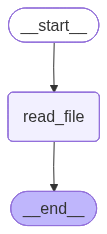

In [5]:
builder = StateGraph(ImageAnalysisState)
builder.add_node("read_file", readfile_node)

builder.add_edge(START, "read_file")
builder.add_edge("read_file", END)

im_graph = builder.compile()
im_graph

In [16]:
result = await im_graph.ainvoke(
    {
        "file_path": "/Users/borisslautin/Downloads/plzt_0004.ibw",
    }
)

In [3]:
import base64
from pathlib import Path


def image_path_to_data_url(path: str | Path) -> str:
    path = Path(path)

    with open(path, "rb") as f:
        b64 = base64.b64encode(f.read()).decode("utf-8")

    return f"data:image/png;base64,{b64}"

In [4]:
from langchain.messages import HumanMessage

def channel_to_text_block(channel_id: str, channel: Channel) -> dict:
    stats = channel.get("stats", "")
    return {
        "type": "text",
        "text": (
            f"Channel ID: {channel_id}\n"
            f"Data type: {channel.get('data_type')}\n"
            f"Title: {channel.get('title')}\n"
            f"Units: {channel.get('units')}\n"
            f"Shape: {str(channel.get('shape'))}\n"
            "Basic statistics:\n"
            f"  min: {stats.get('min')}\n"
            f"  max: {stats.get('max')}\n"
            f"  mean: {stats.get('mean')}\n"
            f"  std: {stats.get('std')}\n"
            f"  p01: {stats.get('p01')}\n"
            f"  p99: {stats.get('p99')}\n\n"
            f"The next image is the preview for {channel_id}."
        ),
    }

def channel_to_image_block(channel: Channel) -> dict:
    image_url = image_path_to_data_url(channel['preview_path'])
    return {
        "type": "image_url",
        "image_url": {
            'url': image_url
            }
    }

def build_channel_recommendation_human_message(file_channels: dict[str, Channel]) -> HumanMessage:
    main_task = {
        "type": "text",
        "text": (
            "Main task:\n"
            "Analyze SPM/PFM image data and select suitable channels for the analysis roles "
            "defined in the system instructions.\n\n"
            "Below are the available channels. For each channel, metadata is given first, "
            "followed immediately by the corresponding preview image."
        )
    }

    human_message_content = [main_task,]
    for ch in file_channels:
        text_message = channel_to_text_block(channel=file_channels[ch], channel_id=ch)
        human_message_content.append(text_message)
        image_message = channel_to_image_block(channel=file_channels[ch])
        human_message_content.append(image_message)


    human_message = HumanMessage(
        content= human_message_content, # pyright: ignore[reportArgumentType]
        ) # type: ignore
    
    return human_message


In [6]:
from langchain_openai import ChatOpenAI

In [7]:
async def channel_recommendation_node(state: ImageAnalysisState) -> ImageAnalysisState:
    human_message = build_channel_recommendation_human_message(state["file_channels"]) # type: ignore
    model = ChatOpenAI(model="gpt-5.4",
                   temperature=0)
    
    structured_model = model.with_structured_output(TaskChannelReccomendationReport)
    
    report = await structured_model.ainvoke([
        system_message,
        human_message,
    ])
    
    return {
        "channel_recommendations": report.model_dump() # type: ignore
    } # type: ignore

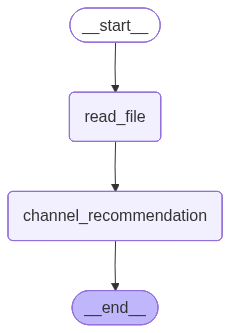

In [8]:
builder = StateGraph(ImageAnalysisState)
builder.add_node("read_file", readfile_node)
builder.add_node("channel_recommendation", channel_recommendation_node)

builder.add_edge(START, "read_file")
builder.add_edge("read_file", "channel_recommendation")
builder.add_edge("channel_recommendation", END)

im_graph = builder.compile()
im_graph

In [9]:
result = await im_graph.ainvoke(
    {
        "file_path": "/Users/borisslautin/Downloads/plzt_0004.ibw",
    }
)

{'task_recommendation': [{'task': 'ferroelectric_domain_segmentation',
   'feasible': True,
   'primary_channel': 'Channel_004',
   'secondary_channels': ['Channel_003', 'Channel_001', 'Channel_002'],
   'confidence': 0.67,
   'reasoning': 'PFM phase channels are the most relevant for ferroelectric domain contrast. Channel_004 shows the strongest broad phase contrast in the preview and is therefore the best candidate for domain segmentation. Channel_003 is a useful supporting phase reference, while amplitude channels can help verify whether apparent contrast is domain-related or dominated by other surface features.',
   'warnings': ['Phase contrast appears mixed with strong texture/topographic imprint, so domain contrast may not be clean.',
    'No clearly ideal high-contrast bipolar domain pattern is visible in the previews; recommendation is moderate-confidence only.']},
  {'task': 'ferroelectric_domain_wall_segmentation',
   'feasible': True,
   'primary_channel': 'Channel_004',
   

In [110]:
model = ChatOpenAI(model="gpt-5.4",
                   temperature=0)

structured_model = model.with_structured_output(TaskChannelReccomendationReport)

In [111]:
response = await structured_model.ainvoke([
    system_message,
    human_message,
])

In [94]:
report = response.model_dump()

In [95]:
report.keys()

dict_keys(['task_reccomendation', 'summary', 'global_warnings', 'overall_confidence'])

In [99]:
report['task_reccomendation']

[{'task': 'ferroelectric_domain_segmentation',
  'feasible': True,
  'primary_channel': 'Channel_004',
  'secondary_channels': ['Channel_003', 'Channel_001', 'Channel_002'],
  'confidence': 0.65,
  'reasoning': 'PFM phase is the most relevant contrast for ferroelectric domain mapping. Channel_004 (Phase2Retrace) shows the strongest broad phase contrast and is the best candidate for separating domains, while Channel_003 provides supporting phase reference. Amplitude channels can help confirm low-response regions near domain transitions or problematic areas.',
  'warnings': ['Phase contrast appears mixed with strong diagonal/textural background, so domain contrast may be partially confounded by topographic or crosstalk features.',
   'No clear bipolar phase-separated domains are obvious in the previews; recommendation is moderate-confidence only.']},
 {'task': 'ferroelectric_domain_wall_segmentation',
  'feasible': True,
  'primary_channel': 'Channel_004',
  'secondary_channels': ['Chann

In [103]:

task_recommendation = {r['task']: r.copy() for r in report['task_reccomendation']}
task_recommendation


{'ferroelectric_domain_segmentation': {'task': 'ferroelectric_domain_segmentation',
  'feasible': True,
  'primary_channel': 'Channel_004',
  'secondary_channels': ['Channel_003', 'Channel_001', 'Channel_002'],
  'confidence': 0.65,
  'reasoning': 'PFM phase is the most relevant contrast for ferroelectric domain mapping. Channel_004 (Phase2Retrace) shows the strongest broad phase contrast and is the best candidate for separating domains, while Channel_003 provides supporting phase reference. Amplitude channels can help confirm low-response regions near domain transitions or problematic areas.',
  'warnings': ['Phase contrast appears mixed with strong diagonal/textural background, so domain contrast may be partially confounded by topographic or crosstalk features.',
   'No clear bipolar phase-separated domains are obvious in the previews; recommendation is moderate-confidence only.']},
 'ferroelectric_domain_wall_segmentation': {'task': 'ferroelectric_domain_wall_segmentation',
  'feasi